In [5]:
import copy

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.func import jacrev


# ============================================================
# Device selection
# Priority: CUDA -> MPS -> CPU
# ============================================================

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


# ============================================================
# Circle dataset
# ============================================================

def sample_circle(n, device=device):
    theta = 2 * np.pi * torch.rand(n, device=device)

    z = torch.stack(
        [
            torch.cos(theta),
            torch.sin(theta),
        ],
        dim=-1,
    )

    return z


def sample_xt(n, device=device):
    z = sample_circle(n, device)

    eps = torch.randn_like(z)

    t = torch.rand(n, 1, device=device)

    x = t * z + (1 - t) * eps

    target_velocity = z - eps

    return x, t, target_velocity


# ============================================================
# Flow matching network
# ============================================================

class FMNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=-1)
        return self.net(inp)

class RadialFM(nn.Module):

    def __init__(self):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(2,32),
            nn.Tanh(),
            nn.Linear(32,32),
            nn.Tanh(),
            nn.Linear(32,1)
        )

    def forward(self,x,t):

        r = torch.linalg.norm(
            x,
            dim=-1,
            keepdim=True
        )

        inp = torch.cat([r,t],dim=-1)

        u = self.mlp(inp)

        return u * x/(r+1e-8)


# ============================================================
# Training with checkpoints every `checkpoint_interval` steps
# ============================================================

def train_checkpoints(
    net,
    total_steps=50000,
    checkpoint_interval=10000,
    batch_size=4096,
    lr=1e-4,
):
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps)

    checkpoints = {}

    for step in range(total_steps + 1):

        if step % checkpoint_interval == 0 and step > 0:
            checkpoints[step] = copy.deepcopy(net.state_dict())

        if step == total_steps:
            break

        x, t, v = sample_xt(batch_size, device=device)

        pred = net(x, t)
        loss = (pred - v).pow(2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step()

        if step % 5000 == 0:
            print(f"step={step:6d}  loss={loss.item():.6f}  lr={scheduler.get_last_lr()[0]:.2e}")

    return checkpoints


net = FMNet().to(device)
checkpoints = train_checkpoints(net)


Using device: mps
step=     0  loss=1.485261  lr=1.00e-04
step=  5000  loss=1.099793  lr=9.76e-05
step= 10000  loss=0.978583  lr=9.04e-05
step= 15000  loss=0.965107  lr=7.94e-05
step= 20000  loss=1.020554  lr=6.54e-05
step= 25000  loss=0.968689  lr=5.00e-05
step= 30000  loss=0.979193  lr=3.45e-05
step= 35000  loss=0.975178  lr=2.06e-05
step= 40000  loss=0.976536  lr=9.55e-06
step= 45000  loss=0.958983  lr=2.45e-06


In [6]:
# ============================================================
# Drift
# ============================================================

def drift(t, x):

    tt = torch.full(
        (x.shape[0], 1),
        t,
        device=x.device,
    )

    return net(x, tt)


# ============================================================
# Jacobian of drift (single point)
# ============================================================

def drift_jacobian(t, x):

    def single(xx):

        tt = torch.tensor(
            [[t]],
            device=xx.device,
            dtype=xx.dtype,
        )

        return net(xx[None], tt)[0]

    return jacrev(single)(x)


# ============================================================
# Batched variational integrator
# Processes all samples in parallel via vmap + bmm
# ============================================================

@torch.no_grad()
def integrate_batched(x0_batch, t0, T, nsteps=500):

    B = x0_batch.shape[0]
    dt = (T - t0) / nsteps

    x = x0_batch.clone()
    J = torch.eye(2, device=x.device, dtype=x.dtype).unsqueeze(0).expand(B, -1, -1).clone()

    batched_jac = torch.vmap(drift_jacobian, in_dims=(None, 0))

    s = t0

    for _ in range(nsteps):

        tt = torch.full((B, 1), s, device=x.device)
        v = net(x, tt)           # (B, 2)
        A = batched_jac(s, x)    # (B, 2, 2)

        x = x + dt * v
        J = J + dt * torch.bmm(A, J)

        s += dt

    return x, J


# ============================================================
# Average eigenvalues — fully batched
# ============================================================

@torch.no_grad()
def average_eigs(t, T, nsamples=200):

    thetas = 2 * np.pi * torch.rand(nsamples, device=device)
    x_batch = torch.stack(
        [torch.cos(thetas), torch.sin(thetas)],
        dim=-1,
    )  # (B, 2), unit circle

    _, J = integrate_batched(x_batch, t, T)  # J: (B, 2, 2)

    # Points are on unit circle so n = x, tau = [-y, x]
    n = x_batch                                              # (B, 2)
    tau = torch.stack([-n[:, 1], n[:, 0]], dim=-1)          # (B, 2)

    mu_perp = (J @ n.unsqueeze(-1)).squeeze(-1).norm(dim=-1).pow(2)   # (B,)
    mu_tan  = (J @ tau.unsqueeze(-1)).squeeze(-1).norm(dim=-1).pow(2) # (B,)

    return mu_perp.mean().item(), mu_tan.mean().item()


# ============================================================
# Evaluate one checkpoint: sweep over ts
# ============================================================

def evaluate_checkpoint(state_dict, ts, T=1 - 1e-6, nsamples=200):
    net.load_state_dict(state_dict)
    net.eval()

    mu_perp_list = []
    mu_tan_list = []

    for t in ts:
        mp, mt = average_eigs(t, T, nsamples=nsamples)
        mu_perp_list.append(mp)
        mu_tan_list.append(mt)

    return np.array(mu_perp_list), np.array(mu_tan_list)


# ============================================================
# Sweep over all training checkpoints
# ============================================================

T = 1 - 1e-6

ts = [
    0.70,
    0.80,
    0.90,
    0.95,
    0.98,
    0.99,
]

theory = np.array([((1 - T) / (1 - t)) ** 2 for t in ts])

checkpoint_results = {}  # step -> (mu_perp, mu_tan)

for step in sorted(checkpoints.keys()):
    print(f"Evaluating checkpoint step={step} ...")
    mp, mt = evaluate_checkpoint(checkpoints[step], ts, T=T)
    checkpoint_results[step] = (mp, mt)
    print(f"  mu_perp/mu_tan @ t=0.99 : {mp[-1] / mt[-1]:.3f}")

# Restore final weights
net.load_state_dict(checkpoints[max(checkpoints)])

# Convenience arrays for single-checkpoint plots (final checkpoint)
mu_perp, mu_tan = checkpoint_results[max(checkpoints)]


Evaluating checkpoint step=10000 ...
  mu_perp/mu_tan @ t=0.99 : 0.939
Evaluating checkpoint step=20000 ...
  mu_perp/mu_tan @ t=0.99 : 0.904
Evaluating checkpoint step=30000 ...
  mu_perp/mu_tan @ t=0.99 : 0.893
Evaluating checkpoint step=40000 ...
  mu_perp/mu_tan @ t=0.99 : 0.888
Evaluating checkpoint step=50000 ...
  mu_perp/mu_tan @ t=0.99 : 0.889


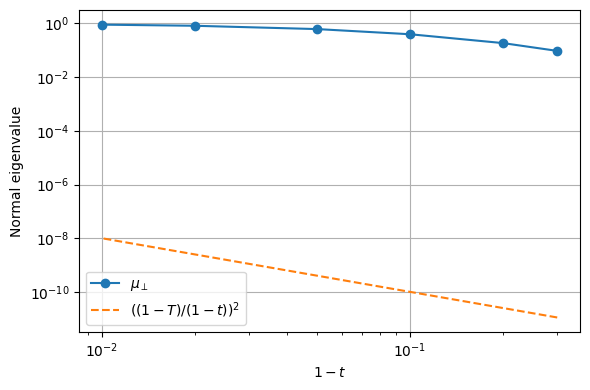

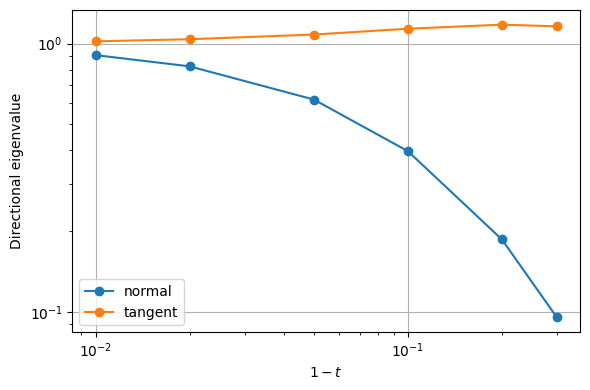

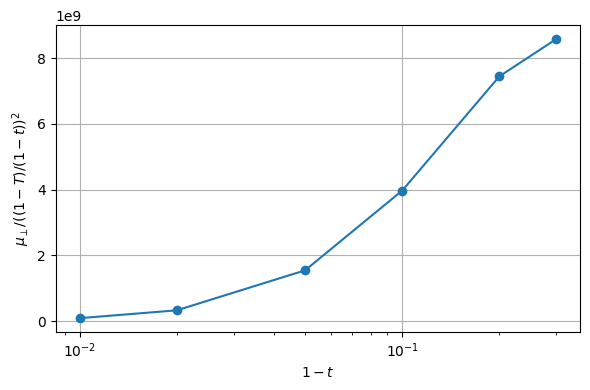


Results (final checkpoint):
t=0.700  mu_perp=9.5352e-02  mu_tan=1.1593e+00
t=0.800  mu_perp=1.8621e-01  mu_tan=1.1766e+00
t=0.900  mu_perp=3.9730e-01  mu_tan=1.1362e+00
t=0.950  mu_perp=6.1867e-01  mu_tan=1.0807e+00
t=0.980  mu_perp=8.2268e-01  mu_tan=1.0383e+00
t=0.990  mu_perp=9.0585e-01  mu_tan=1.0194e+00


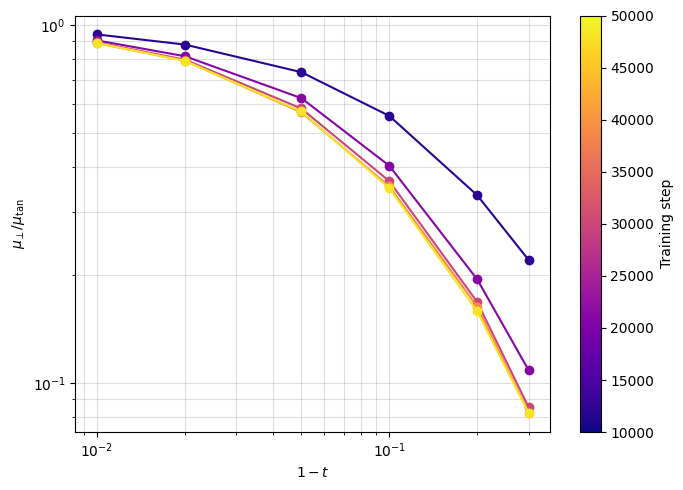

In [7]:
steps_sorted = sorted(checkpoint_results.keys())
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.05, 0.95, len(steps_sorted)))

one_minus_t = 1 - np.array(ts)


# ============================================================
# Plot 1
# Normal eigenvalue vs theory  (final checkpoint)
# ============================================================

plt.figure(figsize=(6, 4))

plt.loglog(
    one_minus_t,
    mu_perp,
    "o-",
    label=r"$\mu_\perp$",
)

plt.loglog(
    one_minus_t,
    theory,
    "--",
    label=r"$((1-T)/(1-t))^2$",
)

plt.xlabel(r"$1-t$")
plt.ylabel("Normal eigenvalue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2
# Tangent vs normal  (final checkpoint)
# ============================================================

plt.figure(figsize=(6, 4))

plt.loglog(
    one_minus_t,
    mu_perp,
    "o-",
    label="normal",
)

plt.loglog(
    one_minus_t,
    mu_tan,
    "o-",
    label="tangent",
)

plt.xlabel(r"$1-t$")
plt.ylabel("Directional eigenvalue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot 3
# mu_perp / theory  (final checkpoint)
# ============================================================

ratio = mu_perp / theory

plt.figure(figsize=(6, 4))

plt.semilogx(
    one_minus_t,
    ratio,
    "o-",
)

plt.xlabel(r"$1-t$")
plt.ylabel(r"$\mu_\perp / ((1-T)/(1-t))^2$")
plt.grid(True)
plt.tight_layout()
plt.show()


print("\nResults (final checkpoint):")
for t, mp, mt in zip(ts, mu_perp, mu_tan):
    print(
        f"t={t:.3f}  "
        f"mu_perp={mp:.4e}  "
        f"mu_tan={mt:.4e}"
    )


# ============================================================
# Plot 4
# mu_perp / mu_tan vs 1-t  coloured by training step
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

for color, step in zip(colors, steps_sorted):
    mp, mt = checkpoint_results[step]
    ax.loglog(
        one_minus_t,
        mp / mt,
        "o-",
        color=color,
        label=f"step {step:,}",
    )

ax.set_xlabel(r"$1-t$")
ax.set_ylabel(r"$\mu_\perp / \mu_\mathrm{tan}$")
ax.grid(True, which="both", alpha=0.4)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=steps_sorted[0], vmax=steps_sorted[-1]),
)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Training step")

plt.tight_layout()
plt.show()
